# Sweep Results
Loads all `best.pt` checkpoints and visualizes val loss and 2AFC across hyperparameters.

In [8]:
import sys
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from config_const import CHECKPOINT_DIR

# ── collect all best.pt checkpoints ──────────────────────────────────────────
records = []
for pt in sorted(CHECKPOINT_DIR.rglob("best.pt")):
    ckpt = torch.load(pt, weights_only=False, map_location="cpu")
    row  = {**ckpt["args"], **ckpt["metrics"], "path": str(pt)}
    records.append(row)

df = pd.DataFrame(records)
print(f"{len(df)} runs loaded")
df.head()

64 runs loaded


,model,bottleneck,hidden,d_model,n_heads,n_layers,dropout,target_noise,epochs,batch_size,lr,weight_decay,temperature,epoch,train_loss,val_loss,val_2afc,path
0,lstm,128,128,64,4,2,0.1,0.0,150,64,0.0003,0.01,0.07,50,0.800130,3.712066,0.691429,/home/yy3658/NeurObjectGen/checkpoints/lstm/h1...
1,lstm,128,128,64,4,2,0.1,0.0,150,64,0.0003,0.10,0.07,60,0.688657,3.703494,0.695102,/home/yy3658/NeurObjectGen/checkpoints/lstm/h1...
2,lstm,128,128,64,4,2,0.1,0.0,150,64,0.0010,0.01,0.07,17,1.338314,3.637584,0.703673,/home/yy3658/NeurObjectGen/checkpoints/lstm/h1...
3,lstm,128,128,64,4,2,0.1,0.0,150,64,0.0010,0.10,0.07,18,1.228835,3.645289,0.715102,/home/yy3658/NeurObjectGen/checkpoints/lstm/h1...
4,lstm,128,128,64,4,2,0.3,0.0,150,64,0.0003,0.01,0.07,64,0.982025,3.665787,0.701633,/home/yy3658/NeurObjectGen/checkpoints/lstm/h1...


In [2]:
# Friendly label for each run
def make_label(row):
    m = row["model"]
    if m == "mlp":
        return f"bn{int(row['bottleneck'])}"
    elif m == "lstm":
        return f"h{int(row['hidden'])}"
    else:
        return f"d{int(row['d_model'])}_nl{int(row['n_layers'])}"

df["arch"]  = df.apply(make_label, axis=1)
df["label"] = df.apply(lambda r: f"{r['model']} {make_label(r)} do={r['dropout']} lr={r['lr']:.0e} wd={r['weight_decay']:.0e}", axis=1)

## Best run per model

In [3]:
cols = ["model", "arch", "dropout", "lr", "weight_decay", "epoch", "train_loss", "val_loss", "val_2afc"]
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values("val_2afc", ascending=False)
      .groupby("model", sort=False)
      .first()
      .reset_index()
)[available]
summary

,model,arch,dropout,lr,weight_decay,epoch,train_loss,val_loss,val_2afc
0,mlp,bn128,0.3,0.0010,0.10,122,0.333931,3.100570,0.848980
1,transformer,d128_nl1,0.3,0.0003,0.01,112,1.045069,3.173098,0.821224
2,lstm,h128,0.3,0.0010,0.10,20,1.794586,3.498948,0.755918


## Val loss vs 2AFC (all runs, coloured by model)

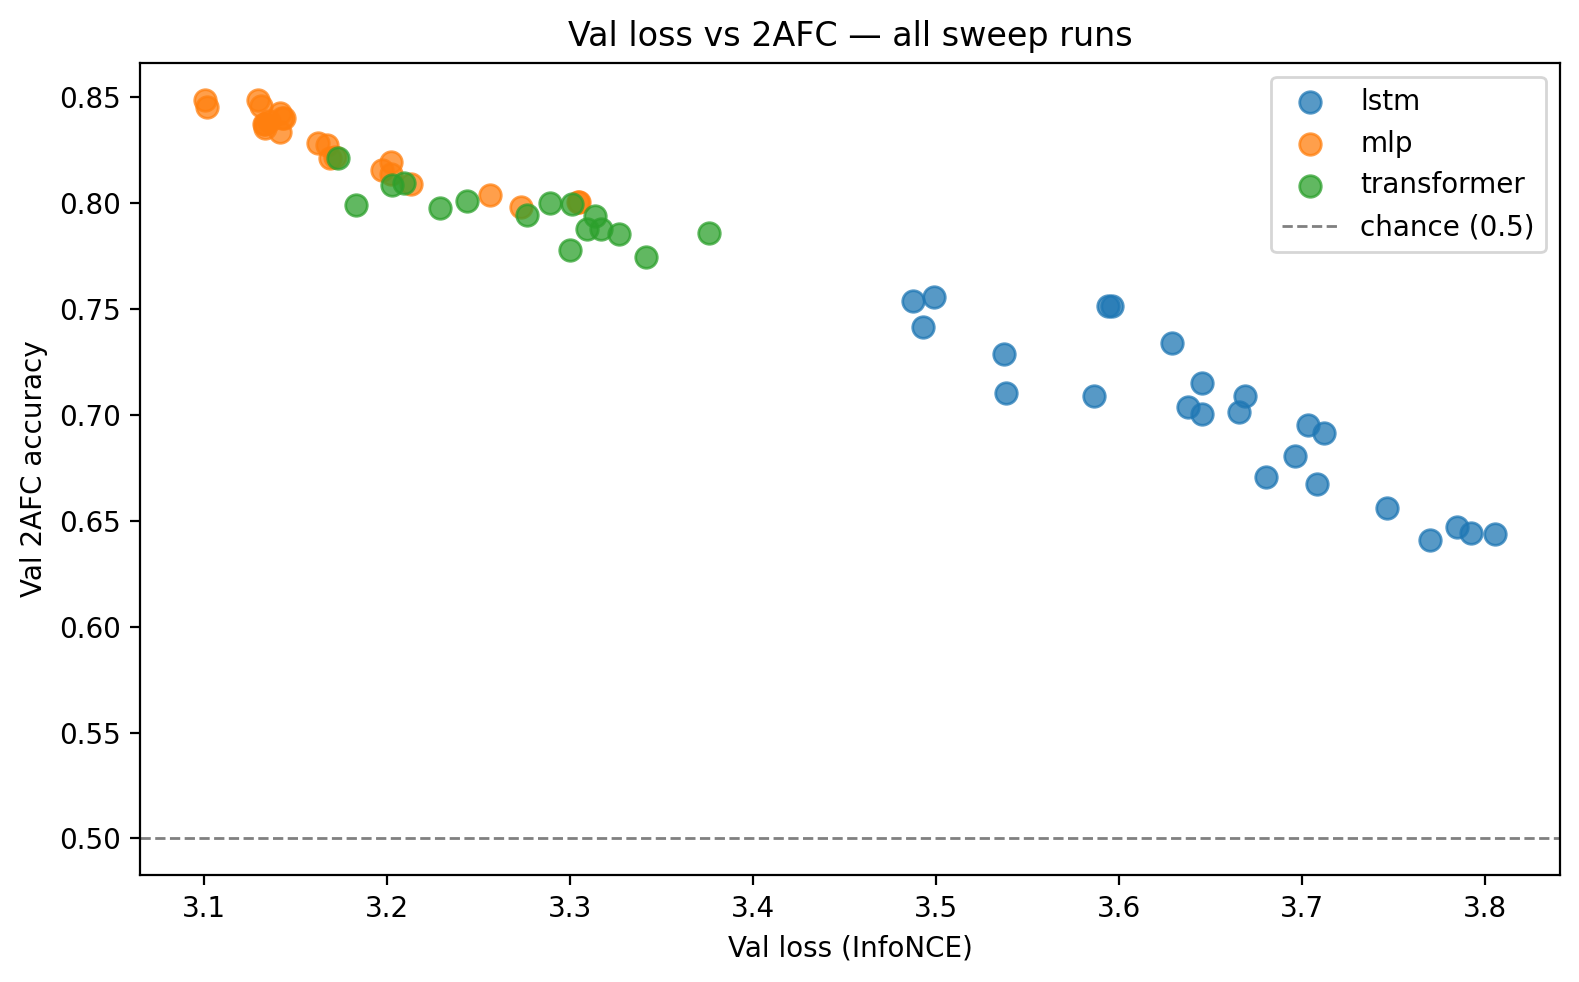

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
models   = df["model"].unique()
palette  = {m: c for m, c in zip(models, ["tab:blue", "tab:orange", "tab:green"])}

for model, grp in df.groupby("model"):
    ax.scatter(grp["val_loss"], grp["val_2afc"],
               label=model, color=palette[model], alpha=0.75, s=60)

ax.axhline(0.5, color="grey", lw=1, ls="--", label="chance (0.5)")
ax.set_xlabel("Val loss (InfoNCE)")
ax.set_ylabel("Val 2AFC accuracy")
ax.set_title("Val loss vs 2AFC — all sweep runs")
ax.legend()
plt.tight_layout()
plt.show()

## 2AFC by hyperparameter — per model

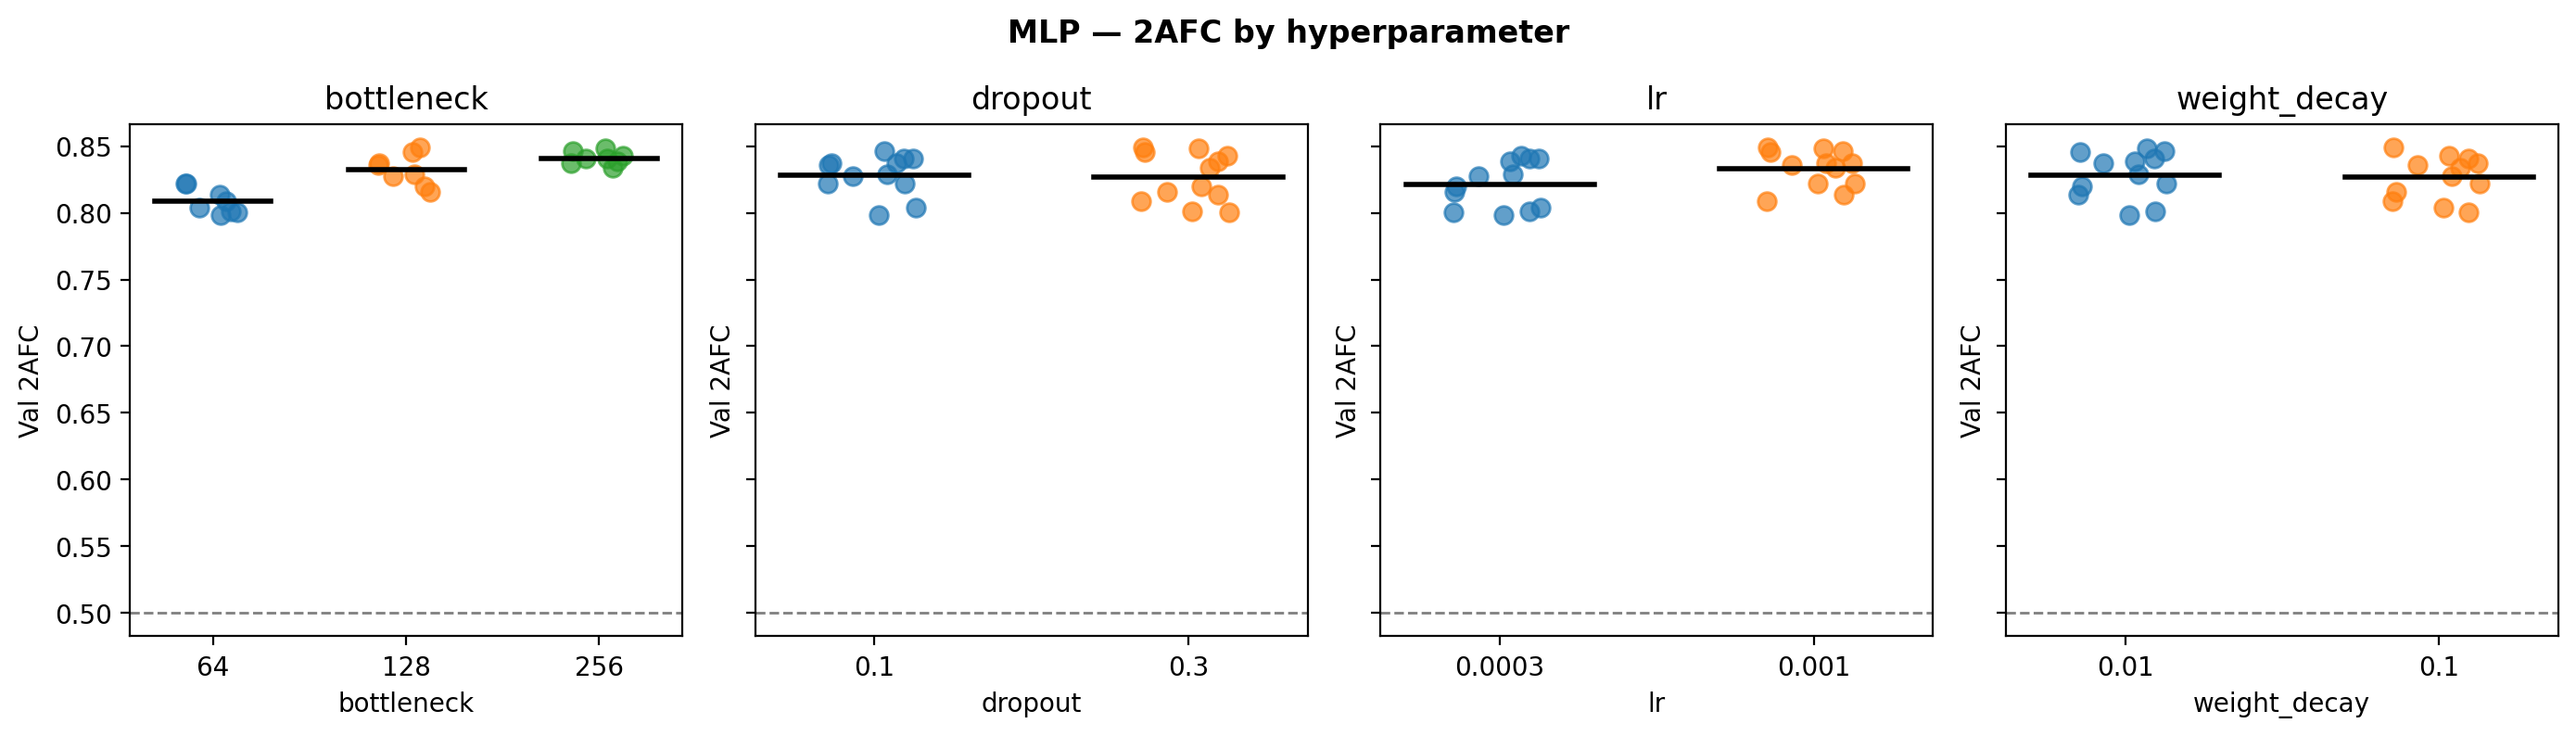

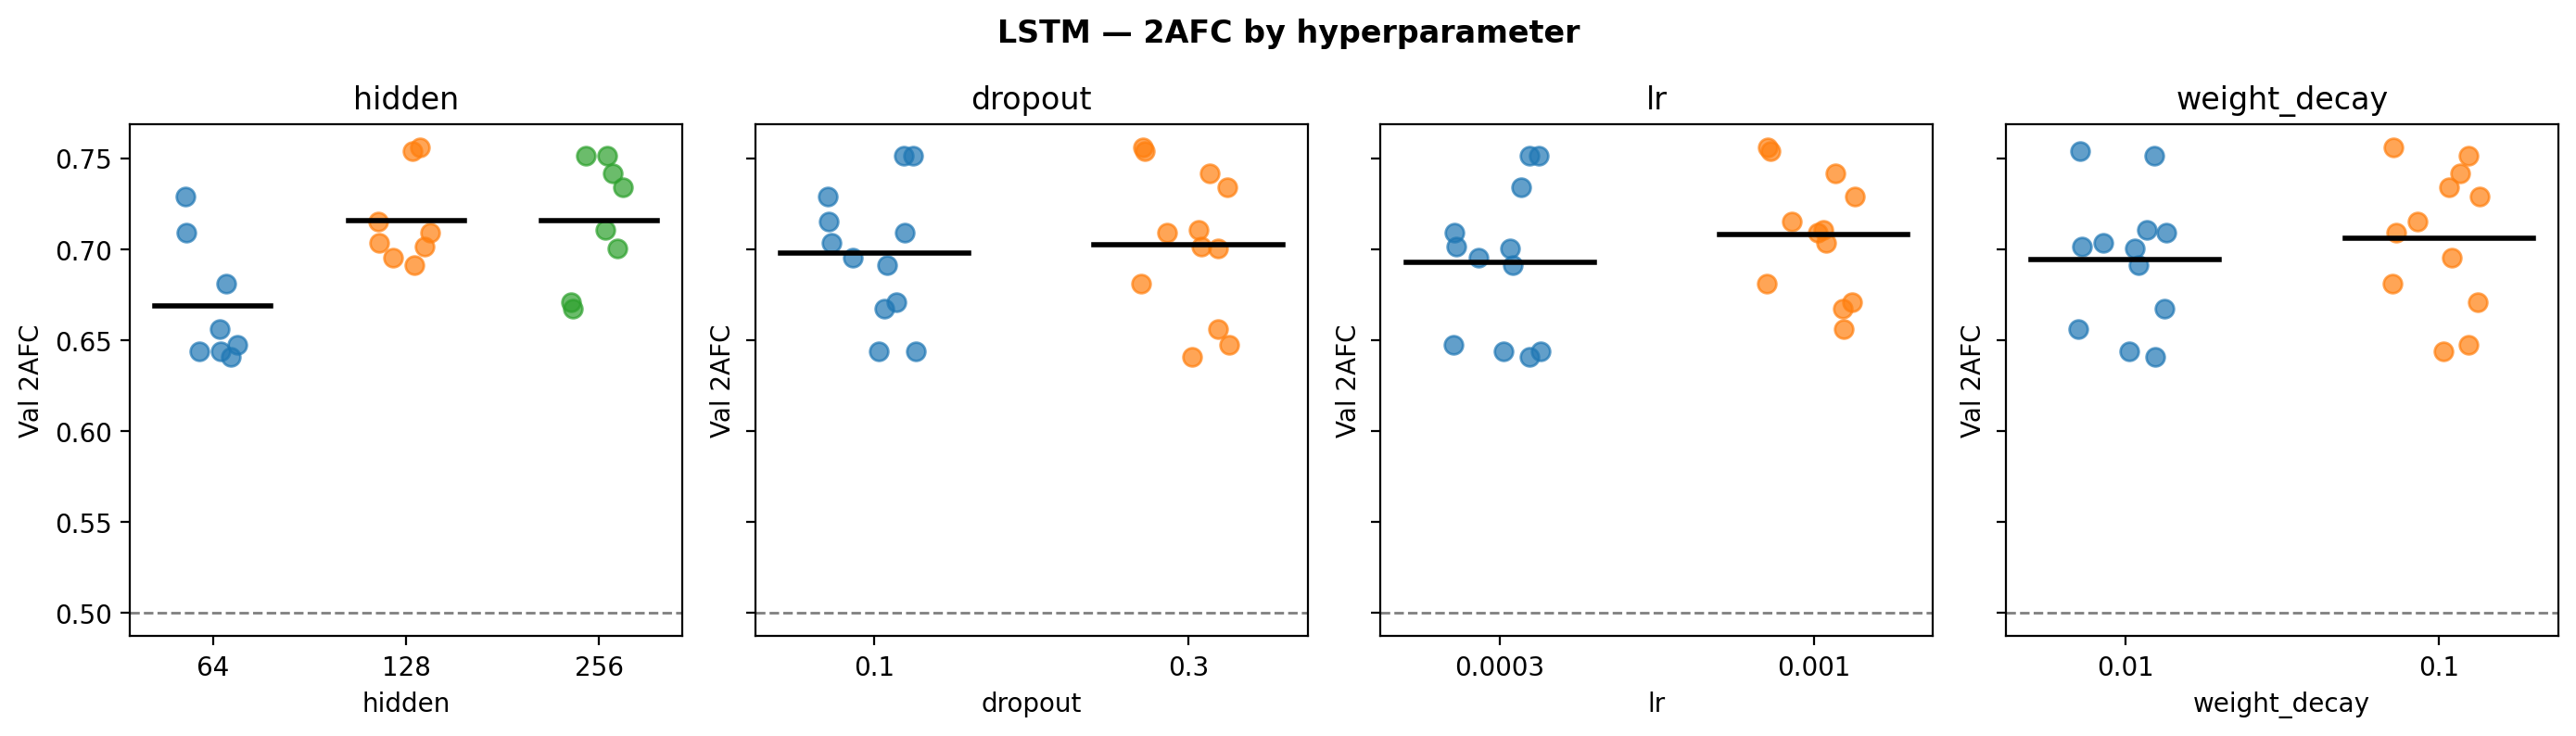

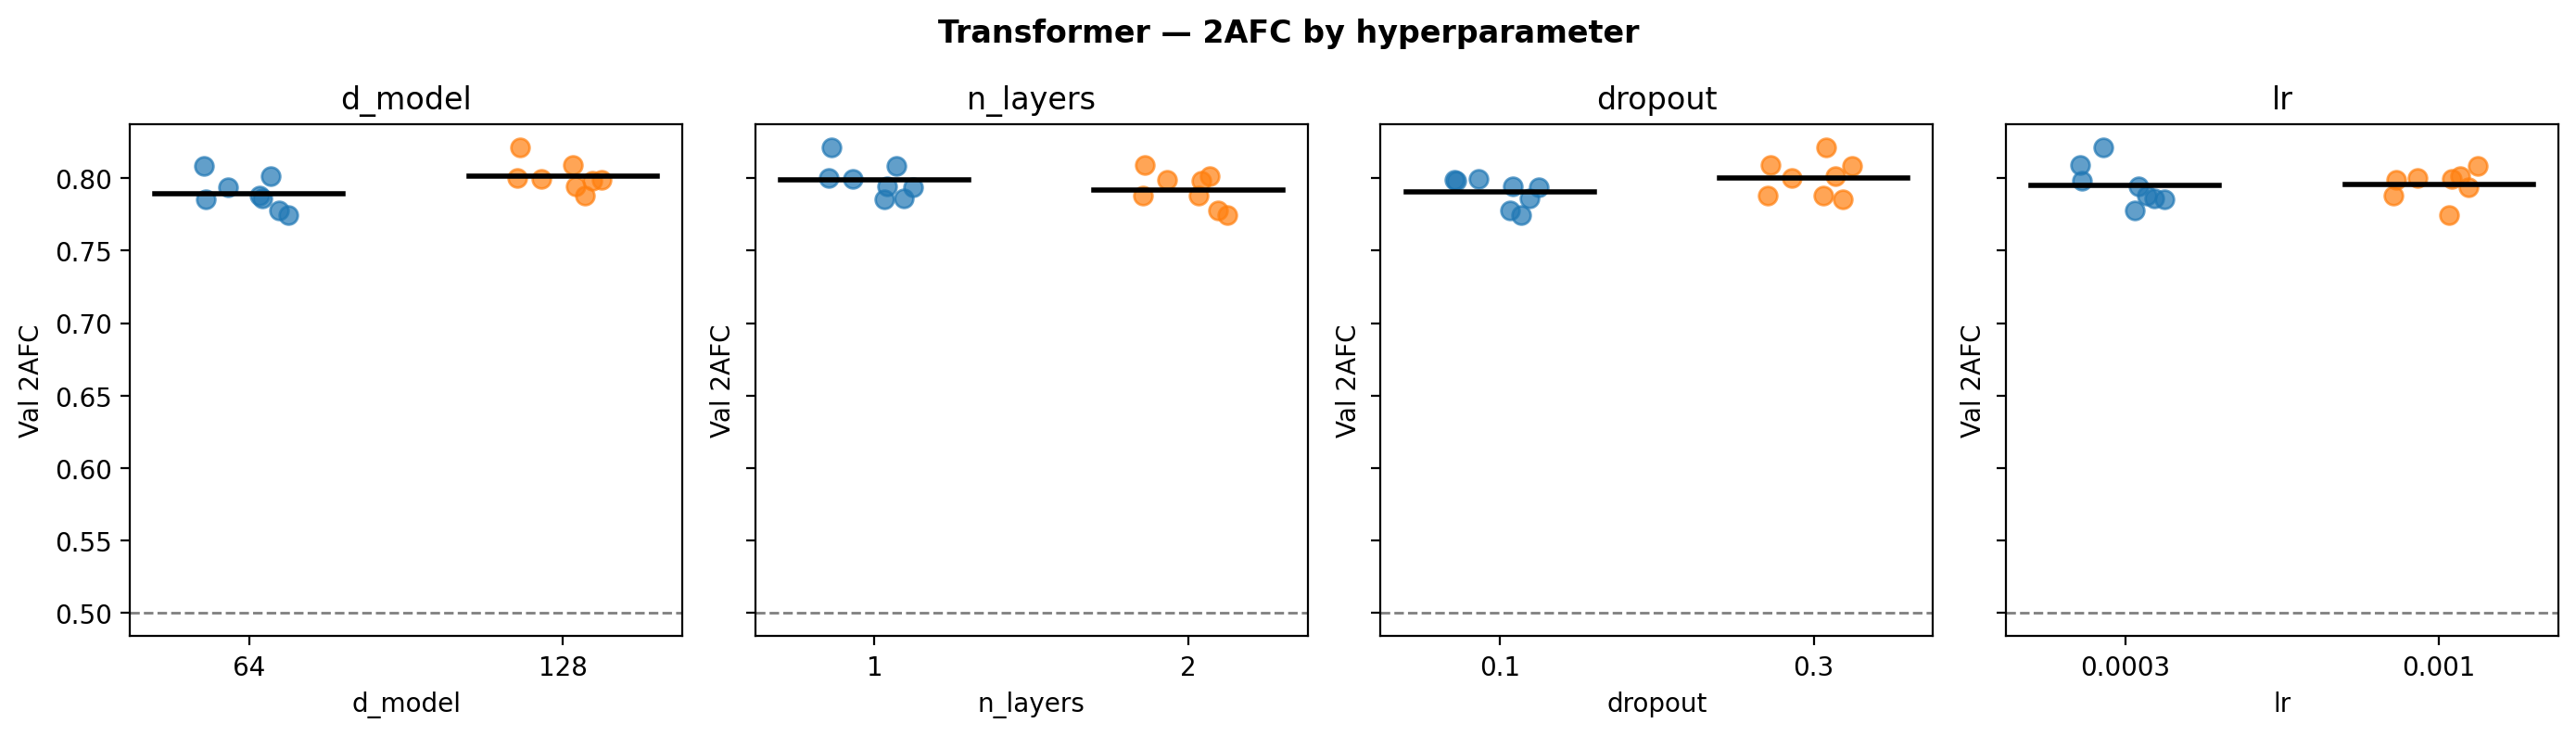

In [5]:
def strip_plot(ax, grp, x_col, title):
    levels = sorted(grp[x_col].unique())
    for i, lvl in enumerate(levels):
        vals = grp.loc[grp[x_col] == lvl, "val_2afc"].values
        jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.7, s=50)
        ax.plot([i - 0.3, i + 0.3], [vals.mean(), vals.mean()], "k-", lw=2)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_xlabel(x_col)
    ax.set_ylabel("Val 2AFC")
    ax.set_title(title)
    ax.axhline(0.5, color="grey", lw=1, ls="--")

# ── MLP ──────────────────────────────────────────────────────────────────────
mlp = df[df["model"] == "mlp"]
if not mlp.empty:
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    fig.suptitle("MLP — 2AFC by hyperparameter", fontweight="bold")
    for ax, col in zip(axes, ["bottleneck", "dropout", "lr", "weight_decay"]):
        if col in mlp.columns:
            strip_plot(ax, mlp, col, col)
    plt.tight_layout()
    plt.show()

# ── LSTM ─────────────────────────────────────────────────────────────────────
lstm = df[df["model"] == "lstm"]
if not lstm.empty:
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    fig.suptitle("LSTM — 2AFC by hyperparameter", fontweight="bold")
    for ax, col in zip(axes, ["hidden", "dropout", "lr", "weight_decay"]):
        if col in lstm.columns:
            strip_plot(ax, lstm, col, col)
    plt.tight_layout()
    plt.show()

# ── Transformer ───────────────────────────────────────────────────────────────
trf = df[df["model"] == "transformer"]
if not trf.empty:
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    fig.suptitle("Transformer — 2AFC by hyperparameter", fontweight="bold")
    for ax, col in zip(axes, ["d_model", "n_layers", "dropout", "lr"]):
        if col in trf.columns:
            strip_plot(ax, trf, col, col)
    plt.tight_layout()
    plt.show()

## Val loss heatmap — LR × weight_decay (per model)

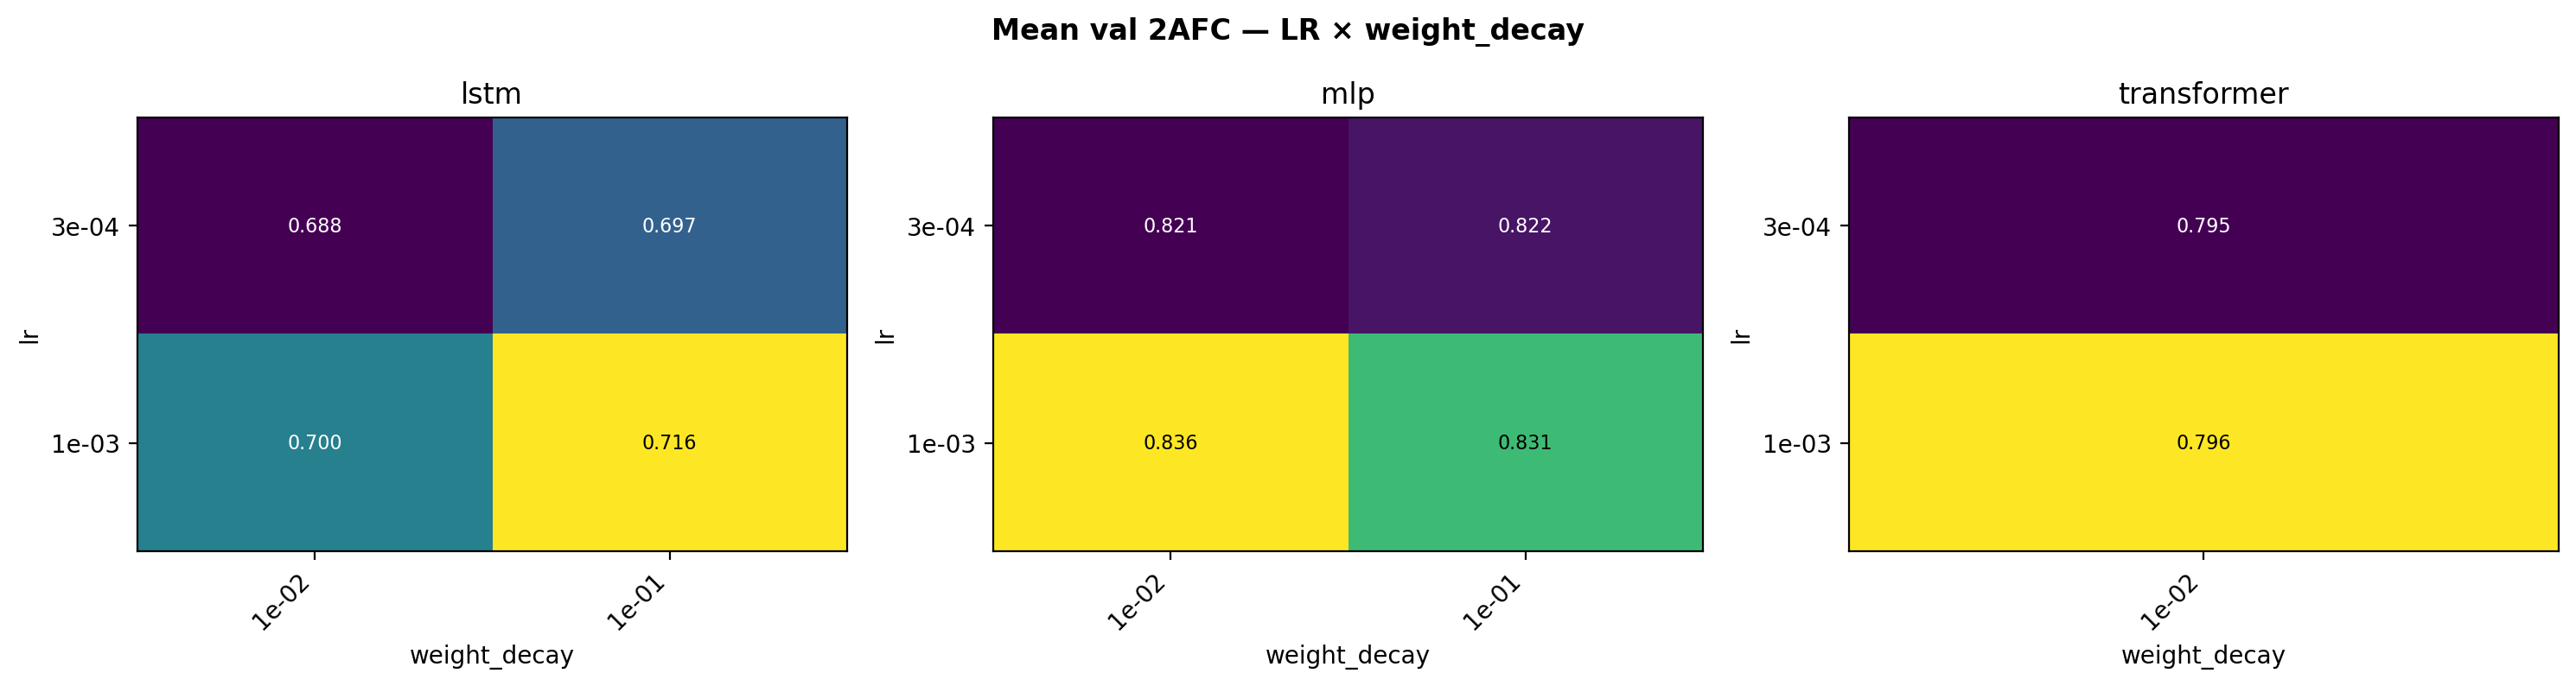

In [6]:
def heatmap(ax, grp, row_col, col_col, val_col, title, cmap="viridis_r", fmt=".3f"):
    pivot = grp.groupby([row_col, col_col])[val_col].mean().unstack()
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.0e}" for v in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.0e}" for v in pivot.index])
    ax.set_xlabel(col_col); ax.set_ylabel(row_col)
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=8,
                        color="white" if v < pivot.values.mean() else "black")
    return im

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Mean val 2AFC — LR × weight_decay", fontweight="bold")

for ax, (model_name, grp) in zip(axes, df.groupby("model")):
    if {"lr", "weight_decay", "val_2afc"}.issubset(grp.columns):
        heatmap(ax, grp, "lr", "weight_decay", "val_2afc", model_name, cmap="viridis", fmt=".3f")

plt.tight_layout()
plt.show()

## Top-10 runs overall

In [7]:
top10_cols = [c for c in ["model", "arch", "dropout", "lr", "weight_decay", "epoch", "val_loss", "val_2afc"] if c in df.columns]
df.sort_values("val_2afc", ascending=False)[top10_cols].head(10).reset_index(drop=True)

,model,arch,dropout,lr,weight_decay,epoch,val_loss,val_2afc
0,mlp,bn128,0.3,0.0010,0.10,122,3.100570,0.848980
1,mlp,bn256,0.3,0.0010,0.01,105,3.129429,0.848571
2,mlp,bn256,0.1,0.0010,0.01,88,3.131137,0.846122
3,mlp,bn128,0.3,0.0010,0.01,122,3.101815,0.845714
4,mlp,bn256,0.3,0.0003,0.10,126,3.141523,0.842449
5,mlp,bn256,0.1,0.0003,0.01,88,3.143774,0.840408
6,mlp,bn256,0.1,0.0003,0.10,88,3.142949,0.840408
7,mlp,bn256,0.3,0.0003,0.01,88,3.135622,0.838776
8,mlp,bn128,0.1,0.0010,0.01,70,3.132868,0.837551
9,mlp,bn256,0.1,0.0010,0.10,91,3.133399,0.837551
